# DECam streak IDs

A notebook that uses DECam observation info to query the SatChecker Field Of View (FOV) service.
The goal is to identify which satellites were passing through the FOV during the observation.

In [1]:
%matplotlib widget

In [2]:
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.utils.data import download_file
import matplotlib.pyplot as plt
import numpy as np
import requests
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import pandas as pd

### Load Alex's DECam telemetry and streaks tables

In [3]:
telemetry1 = pd.read_csv('decam_telemetry_20230817.csv')

In [4]:
telemetry1

,EXPNUM,BAND,TELESCOP,OBSERVAT,INSTRUME,OBS-LONG,OBS-LAT,OBS-ELEV,TELEQUIN,TIMESYS,DATE-OBS,TIME-OBS,DARKTIME,EXPTIME,RA,DEC,AZ,ZD
0,140520,r,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2012-10-20 00:25:35.429106,00:25:35.429106,2.10353,1.0,22:08:24.000,-32:59:17.599,116.2500,7.09
1,140521,r,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2012-10-20 00:29:50.667562,00:29:50.667562,2.09597,1.0,22:08:23.970,-32:55:57.799,118.9300,6.25
2,140522,u,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2012-10-20 00:46:16.576959,00:46:16.576959,31.09820,30.0,18:03:35.240,-30:02:00.600,254.2700,50.20
3,140523,u,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2012-10-20 00:47:44.370016,00:47:44.370016,31.09300,30.0,18:03:35.250,-30:02:00.802,254.1500,50.50
4,140524,u,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2012-10-20 00:49:47.211636,00:49:47.211636,31.09170,30.0,18:03:35.240,-30:02:00.802,253.9900,50.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506513,1228730,g,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2023-08-03 08:42:53.917964,08:42:53.917964,81.10140,80.0,03:30:36.090,-28:05:58.200,97.1620,36.05
506514,1228731,r,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2023-08-03 08:44:44.058111,08:44:44.058111,71.12170,70.0,03:30:36.079,-28:05:58.200,97.0003,35.66
506515,1228732,r,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2023-08-03 08:46:22.681357,08:46:22.681357,71.10870,70.0,03:30:36.090,-28:05:58.200,96.8515,35.30
506516,1228733,i,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2023-08-03 08:48:02.549261,08:48:02.549261,91.09020,90.0,03:30:36.112,-28:05:58.099,96.7036,34.94


In [5]:
telemetry1.columns

Index(['EXPNUM', 'BAND', 'TELESCOP', 'OBSERVAT', 'INSTRUME', 'OBS-LONG',
       'OBS-LAT', 'OBS-ELEV', 'TELEQUIN', 'TIMESYS', 'DATE-OBS', 'TIME-OBS',
       'DARKTIME', 'EXPTIME', 'RA', 'DEC', 'AZ', 'ZD'],
      dtype='object')

In [6]:
streaks1 = pd.read_csv('streaks_augmented_20230817.csv')

In [7]:
streaks1

,filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band
0,D00145425_g_c03_r4148p01_hstreak.fits,3,1.159330,1.160919,1.164310,1.162720,-28.724241,-28.724212,-28.857155,-28.857183,145425,3,g
1,D00145425_g_c06_r4148p01_hstreak.fits,1,0.986677,0.986711,0.644209,0.644186,-29.032018,-29.034283,-29.037208,-29.034944,145425,6,g
2,D00145425_g_c09_r4148p01_hstreak.fits,1,0.452852,0.452942,0.109842,0.109782,-29.193042,-29.199694,-29.203265,-29.196615,145425,9,g
3,D00145425_g_c15_r4148p01_hstreak.fits,1,0.286716,0.286812,0.630816,0.630741,-29.363308,-29.358405,-29.362739,-29.367644,145425,15,g
4,D00145425_g_c16_r4148p01_hstreak.fits,1,0.985852,0.987446,0.987211,0.985615,-29.216748,-29.216752,-29.366385,-29.366381,145425,16,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...
879115,D01223535_g_c05_r6224p01_hstreak.fits,1,323.500201,323.502653,323.444690,323.442238,-17.828499,-17.830897,-17.884254,-17.881855,1223535,5,g
879116,D01223535_g_c31_r6224p01_hstreak.fits,1,324.355544,324.369908,324.372363,324.357994,-18.392109,-18.391941,-18.541070,-18.541235,1223535,31,g
879117,D01223535_g_c56_r6224p01_hstreak.fits,1,322.914589,322.934330,322.849385,322.829651,-19.193809,-19.210870,-19.298406,-19.281342,1223535,56,g
879118,D01223535_g_c58_r6224p01_hstreak.fits,1,323.771850,323.783894,323.835739,323.823696,-19.214779,-19.204086,-19.255903,-19.266598,1223535,58,g


### Choose your DECam expnum of interest here

In [8]:
#expnum = 1033925
#expnum = 1061946
#expnum = 1049047
#expnum = 1134933
#expnum = 1138498
#expnum = 1072590
#expnum = 1161471

#expnum = 1103448  # 4 starlinks
expnum = 1011967

one_streak_obs = telemetry1.loc[(telemetry1['EXPNUM'] == expnum)]

In [9]:
one_streak_obs

,EXPNUM,BAND,TELESCOP,OBSERVAT,INSTRUME,OBS-LONG,OBS-LAT,OBS-ELEV,TELEQUIN,TIMESYS,DATE-OBS,TIME-OBS,DARKTIME,EXPTIME,RA,DEC,AZ,ZD
429517,1011967,i,CTIO 4.0-m telescope,CTIO,DECam,70.8149,-30.1661,2215,2000,UTC,2021-07-05 09:17:38.568323,09:17:38.568323,151.239,150.0,23:54:33.757,-10:20:07.998,18.9481,20.92


### Hard-wired DECam parameters

Original source: https://github.com/DarkEnergySurvey/drawDECam

In [10]:
CCDSECTIONS = {
    1: [2049, 4096, 8193, 12288],
    2: [2049, 4096, 12289, 16384],
    3: [2049, 4096, 16385, 20480],
    4: [4097, 6144, 6145, 10240],
    5: [4097, 6144, 10241, 14336],
    6: [4097, 6144, 14337, 18432],
    7: [4097, 6144, 18433, 22528],
    8: [6145, 8192, 4097, 8192],
    9: [6145, 8192, 8193, 12288],
    10: [6145, 8192, 12289, 16384],
    11: [6145, 8192, 16385, 20480],
    12: [6145, 8192, 20481, 24576],
    13: [8193, 10240, 2049, 6144],
    14: [8193, 10240, 6145, 10240],
    15: [8193, 10240, 10241, 14336],
    16: [8193, 10240, 14337, 18432],
    17: [8193, 10240, 18433, 22528],
    18: [8193, 10240, 22529, 26624],
    19: [10241, 12288, 2049, 6144],
    20: [10241, 12288, 6145, 10240],
    21: [10241, 12288, 10241, 14336],
    22: [10241, 12288, 14337, 18432],
    23: [10241, 12288, 18433, 22528],
    24: [10241, 12288, 22529, 26624],
    25: [12289, 14336, 1, 4096],
    26: [12289, 14336, 4097, 8192],
    27: [12289, 14336, 8193, 12288],
    28: [12289, 14336, 12289, 16384],
    29: [12289, 14336, 16385, 20480],
    30: [12289, 14336, 20481, 24576],
    31: [12289, 14336, 24577, 28672],
    32: [14337, 16384, 1, 4096],
    33: [14337, 16384, 4097, 8192],
    34: [14337, 16384, 8193, 12288],
    35: [14337, 16384, 12289, 16384],
    36: [14337, 16384, 16385, 20480],
    37: [14337, 16384, 20481, 24576],
    38: [14337, 16384, 24577, 28672],
    39: [16385, 18432, 2049, 6144],
    40: [16385, 18432, 6145, 10240],
    41: [16385, 18432, 10240, 14335],
    42: [16385, 18432, 14336, 18431],
    43: [16385, 18432, 18432, 22527],
    44: [16385, 18432, 22528, 26623],
    45: [18433, 20480, 2049, 6144],
    46: [18433, 20480, 6145, 10240],
    47: [18433, 20480, 10240, 14335],
    48: [18433, 20480, 14336, 18431],
    49: [18433, 20480, 18432, 22527],
    50: [18433, 20480, 22528, 26623],
    51: [20481, 22528, 4097, 8192],
    52: [20481, 22528, 8193, 12288],
    53: [20481, 22528, 12289, 16384],
    54: [20481, 22528, 16385, 20480],
    55: [20481, 22528, 20481, 24576],
    56: [22529, 24576, 6145, 10240],
    57: [22529, 24576, 10240, 14335],
    58: [22529, 24576, 14336, 18431],
    59: [22529, 24576, 18432, 22527],
    60: [24577, 26624, 8193, 12288],
    61: [24577, 26624, 12289, 16384],
    62: [24577, 26624, 16385, 20480]
}

CCDSECTION_X0 = (CCDSECTIONS[28][1] + CCDSECTIONS[35][0]) / 2.0
CCDSECTION_Y0 = (CCDSECTIONS[35][2] + CCDSECTIONS[28][3]) / 2.0

TRIM_CCDSECTIONS = CCDSECTIONS.copy()
borderpix = 104  # 208/2. as 208 is the space between chips in pixels
for _k, _v in list(TRIM_CCDSECTIONS.items()):
    (_x1, _x2, _y1, _y2) = _v
    _x1 = _x1 + borderpix
    _x2 = _x2 - borderpix
    _y1 = _y1 + borderpix
    _y2 = _y2 - borderpix
    TRIM_CCDSECTIONS[_k] = [_x1, _x2, _y1, _y2]

def createDECam_TANheader(ra_center, dec_center, pixscale=0.2634):
    """
    Creates a fake TAN projection header for DECam image to project the
    CCD Sections on the sky
    pixscale is in arcseconds per pixel
    """
    DECam_header = {
        'CTYPE1': 'RA---TAN',  # / WCS projection type for this axis
        'CTYPE2': 'DEC--TAN',  # / WCS projection type for this axis
        'CUNIT1': 'deg',  # / Axis unit
        'CUNIT2': 'deg',  # / Axis unit
        'CRVAL1': ra_center,  # / World coordinate on this axis
        'CRPIX1': CCDSECTION_X0,  # / Reference pixel on this axis
        'CD1_1': 0,  # /
        'CD1_2': +pixscale / 3600.,  # /
        'CRVAL2': dec_center,  # /
        'CRPIX2': CCDSECTION_Y0,  # /
        'CD2_1': -pixscale / 3600.,  # /
        'CD2_2': 0.  # /
    }
    return DECam_header

### SatChecker query parameters

Must specify the observatory location, the sky region, and the time and duration of the observation.
Docs available at https://satchecker.readthedocs.io/en/latest/fov.html

In [11]:
fov_radius = 1.5  # degree radius for the satchecker query
# NOTE DECam FOV is 3 square degrees (2.2 degrees across)
location = EarthLocation.of_site('ctio')
latitude = location.lat.value  # deg
longitude = location.lon.value  # deg
elevation = location.height.value  # meters

In [12]:
exp_time = one_streak_obs['EXPTIME'].values[0]*u.s
exp_begin = Time(one_streak_obs['DATE-OBS'].values[0])

start_time_jd = exp_begin.jd
duration = exp_time.value

# OPTION to make the query time window will go from T0 - Texp to T0 + 2*Texp, for a total duration of 3*Texp

#start_time_jd = (exp_begin - exp_time).jd
#duration = (exp_time * 3).value

In [13]:
coord = SkyCoord(ra=one_streak_obs['RA'].values[0], dec=one_streak_obs['DEC'].values[0], unit=(u.hourangle, u.deg))
# DECam defaults are HOURANGLES for RA and DEGREES for Dec, because they like to make you suffer

In [14]:
ra_center = coord.icrs.ra.value
dec_center = coord.icrs.dec.value

In [15]:
# Make the SatChecker API request
url_string = f"https://satchecker.cps.iau.org/fov/satellite-passes/?latitude={latitude}&longitude={longitude}&elevation={elevation}&start_time_jd={start_time_jd}&duration={duration}&ra={ra_center}&dec={dec_center}&fov_radius={fov_radius}&group_by=satellite"
response = requests.get(url_string, timeout=60)
data = response.json()
print(url_string)

https://satchecker.cps.iau.org/fov/satellite-passes/?latitude=-30.165277777777778&longitude=-70.815&elevation=2214.9999999993697&start_time_jd=2459400.887251948&duration=150.0&ra=358.6406541666666&dec=-10.335555000000001&fov_radius=1.5&group_by=satellite


In [16]:
# Extract RA/Dec positions for each satellite
satellites = {}

for sat_key, sat_data in data['data']['satellites'].items():
    if sat_key not in satellites:
        satellites[sat_key] = []
    # Add ra, dec, and julian_date from each position
    for position in sat_data['positions']:
        satellites[sat_key].append([
            position['ra'],
            position['dec'],
            position['julian_date']
        ])

print(f"Public catalog satellites passing through the specified FOV, as seen from CTIO, starting at {start_time_jd} JD for {duration} seconds:")
for sat in satellites:
    print(f"{sat}: {len(satellites[sat])} points")

Public catalog satellites passing through the specified FOV, as seen from CTIO, starting at 2459400.887251948 JD for 150.0 seconds:
ATLAS 2AS CENTAUR R/B (26072): 121 points
DELTA 2 R/B (24797): 7 points
OV1-14 R/B (3177): 2 points


### Optional - Access header data from NOIRLab Data Archive

This is overkill here because a mini WCS-only header with the correct CRPIX offsets should be sufficient

In [17]:
def getDecamHeader(expnum, detector=28):
    natroot = 'https://astroarchive.noirlab.edu'
    adsurl = f'{natroot}/api/adv_search'
    jj = {
        "outfields" : [
            "md5sum",
            "archive_filename",
            "dateobs_center",
            "dateobs_min",
            "dateobs_max",
            "proc_type",
            "prod_type",
            "obs_type",
            "release_date",
            "proposal",
            "caldat",
            "EXPNUM",    # AUX field. Slows search
        ],
        "search" : [
            ["instrument", "decam"],
            ["proc_type", "instcal"],
            ["EXPNUM", expnum, expnum],
            ["prod_type", "image"],
        ]
    }
    apiurl = f'{adsurl}/find/?limit=20'
    print(f'Using API url: {apiurl}')
    data = requests.post(apiurl,json=jj).json()
    query_result = pd.DataFrame(data[1:])
    md5sum = query_result['md5sum'][0]
    access_url = f'https://astroarchive.noirlab.edu/api/retrieve/{md5sum}/?hdus={detector}'
    filename = download_file(access_url, cache=True)
    print(filename)
    hdu_list = fits.open(filename)
    #print(hdu_list.info())
    header = hdu_list[1].header
    return header

In [18]:
#header_download = getDecamHeader(expnum)  # SLOW this will DOWNLOAD THINGS
##print(header_download)
#wcstest = WCS(header)
#print(wcstest)

### Plot the satellites in the FOV

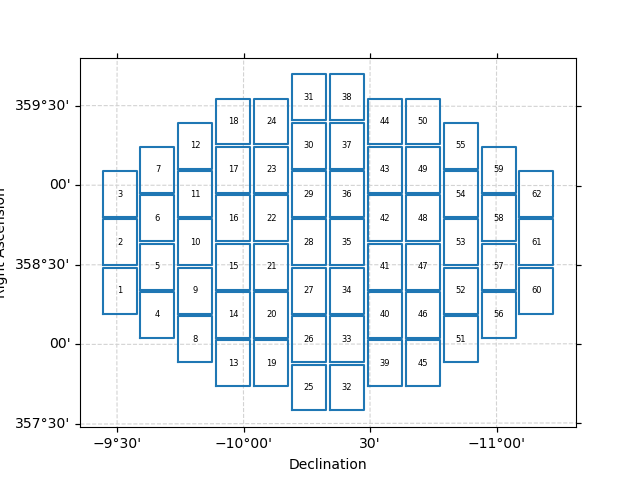

In [19]:
# First, just the DECam focal plane, for debugging purposes
# This correctly plots the focal plane in "pixel orientation," per
# See https://noirlab.edu/science/programs/ctio/instruments/Dark-Energy-Camera/characteristics

fig = plt.figure()
decam_header = createDECam_TANheader(ra_center, dec_center)
wcs1 = WCS(decam_header, naxis=2)

ax = fig.add_subplot(1, 1, 1, projection=wcs1)

for k, v in list(TRIM_CCDSECTIONS.items()):
    (x1, x2, y1, y2) = v
    x = np.array([x1, x2, x2, x1, x1])
    y = np.array([y1, y1, y2, y2, y1])
    
    plot_coords = wcs1.pixel_to_world(x, y)
    ax.plot(plot_coords.ra, plot_coords.dec, c='C0', transform=ax.get_transform('world'))
    # Labels for each detector number
    text_coords1 = wcs1.pixel_to_world(x1, y1)
    text_coords2 = wcs1.pixel_to_world(x2, y2)
    ax.text(0.5 * (text_coords2.ra.value + text_coords1.ra.value), 0.5 * (text_coords2.dec.value + text_coords1.dec.value),
            f'{k}', ha='center', va='center', size=6, transform=ax.get_transform('world'))

#ax.invert_xaxis()
ax.coords.grid(color='lightgray', linestyle='--')
raax = ax.coords['pos.eq.ra']
raax.set_format_unit('deg')
raax.set_axislabel('Right Ascension')
decax = ax.coords['pos.eq.dec']
decax.set_format_unit('deg')
decax.set_axislabel('Declination')

#ax.scatter(20, 3, s=20, c='C1', transform=ax.get_transform('world'))
#ax.scatter(21, 3, s=20, c='C2', transform=ax.get_transform('world'))

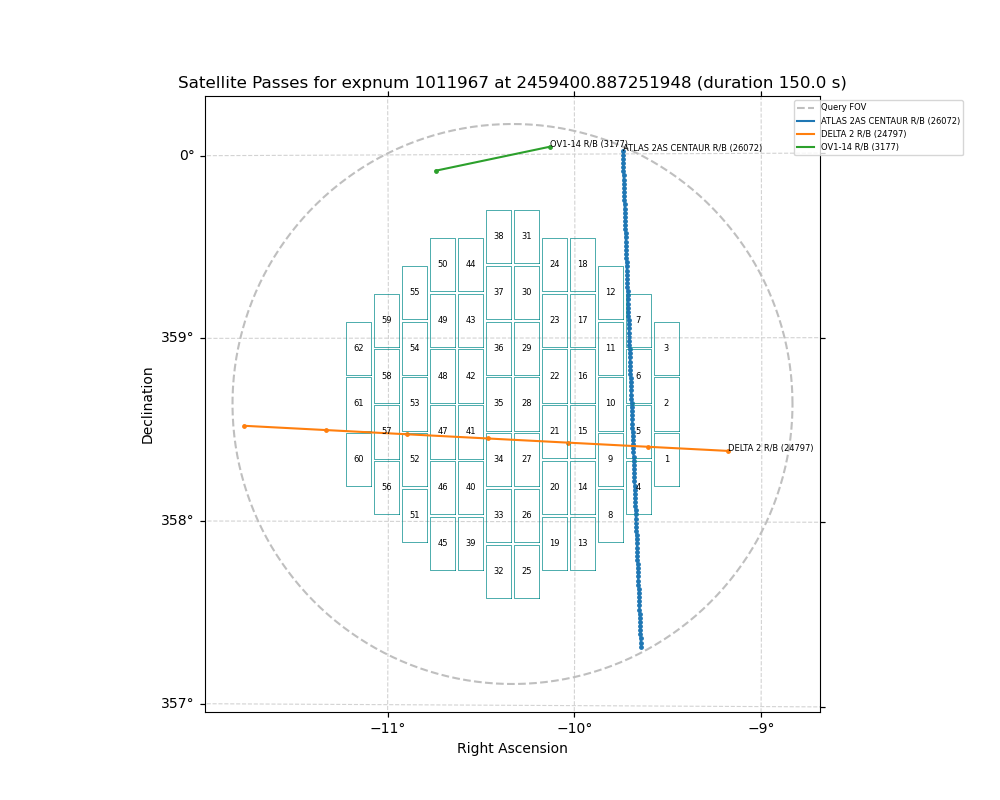

In [20]:
# Now, the actual plot we want to make, in principle

fig = plt.figure(figsize=(10,8))

# Add DECam focal plane footprint to the plot
wcs1 = WCS(createDECam_TANheader(ra_center, dec_center), naxis=2)

#print(wcs1)
ax = fig.add_subplot(1, 1, 1, projection=wcs1)

for k, v in list(TRIM_CCDSECTIONS.items()):
    (x1, x2, y1, y2) = v
    x = np.array([x1, x2, x2, x1, x1])
    y = np.array([y1, y1, y2, y2, y1])
    plot_coords = wcs1.pixel_to_world(x, y)
    ax.plot(plot_coords.ra.value, plot_coords.dec.value, color="#058B8C", lw=0.5, transform=ax.get_transform('world'))

    # Labels for each detector number
    text_coords1 = wcs1.pixel_to_world(x1, y1)
    text_coords2 = wcs1.pixel_to_world(x2, y2)
    ax.text(0.5 * (text_coords2.ra.value + text_coords1.ra.value), 0.5 * (text_coords2.dec.value + text_coords1.dec.value),
            f'{k}', ha='center', va='center', size=6, transform=ax.get_transform('world'))

# Add SatChecker query info to the plot
center = SkyCoord(ra=ra_center*u.deg, dec=dec_center*u.deg, frame='icrs')
position_angles = np.linspace(0, 360, 360) * u.deg
circle_points = center.directional_offset_by(position_angles, fov_radius * u.deg)

# Query FOV
ax.plot(circle_points.ra.deg, circle_points.dec.deg, 
        c='0.75', ls='--', label='Query FOV',
        transform=ax.get_transform('world'),
       )

# Satellite tracks
for sat_name in satellites.keys():
    ra = [pos[0] for pos in satellites[sat_name]]
    dec = [pos[1] for pos in satellites[sat_name]]
    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    
    # Satellite track
    ax.plot(coords.ra.deg, coords.dec.deg, 
            transform=ax.get_transform('world'),
            label=sat_name)
        
    # Satellite position points
    ax.scatter(coords.ra.deg, coords.dec.deg, 
               transform=ax.get_transform('world'),
               s=6)
    
    # Start and end labels
    times = [pos[2] for pos in satellites[sat_name]]
    if coords.ra.deg[0] < coords.ra.deg[-1]:
        ax.text(coords.ra.deg[0], coords.dec.deg[0], f'{sat_name}', 
                transform=ax.get_transform('world'),
                fontsize="6")  
    else:
        ax.text(coords.ra.deg[-1], coords.dec.deg[-1], f'{sat_name}', 
            transform=ax.get_transform('world'),
            fontsize="6")

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(0.95, 1), loc='upper left', fontsize="6")
ax.set_xlabel('Right Ascension')
ax.invert_xaxis()
ax.coords[0].set_format_unit('deg')
ax.coords[1].set_format_unit('deg')
ax.set_ylabel('Declination')
ax.set_title(f'Satellite Passes for expnum {expnum} at {start_time_jd} (duration {duration:.1f} s)') 
ax.grid(color='lightgray', linestyle='--')

In [21]:
# Example of the kind of shenanigans required to display a DECam image array in the "usual" orientation

#fig = plt.figure(figsize=(10,10))
#plt.imshow(np.flip(image.T), origin='lower', vmin = np.percentile(image,5), vmax = np.percentile(image, 95))

## Download some DECam images

Bonus side quest section

Save them for later or whatever

In [22]:
def load_decam_image(expnum, detector):
    """
   Load a  DECam image given the exposure number (expnum) and detector number (HDU).
    """
    natroot = 'https://astroarchive.noirlab.edu'
    adsurl = f'{natroot}/api/adv_search'

    jj = {
        "outfields": ["md5sum", "archive_filename", "EXPNUM"],
        "search": [
            ["instrument", "decam"],
            ["proc_type", "instcal"],
            ["EXPNUM", expnum, expnum],
            ["prod_type", "image"],
        ]
    }

    apiurl = f'{adsurl}/find/?limit=1'
    data = requests.post(apiurl, json=jj).json()

    if len(data) < 2:
        raise ValueError(f"No image was found for expnum {expnum}")

    query_result = data[1]
    md5sum = query_result['md5sum']

    access_url = f'{natroot}/api/retrieve/{md5sum}/?hdus={detector}'
    filename = download_file(access_url, cache=True)
    print(f'Image expnum {expnum} ccdnum {detector} saved to {filename}')

    #hdu_list = fits.open(filename)
    #image = hdu_list[1].data
    #header = hdu_list[1].header
    #header_expnum = hdu_list[0].header

    #return image, header, header_expnum

In [23]:
#load_decam_image(1033925, 17)

In [24]:
#decam_expnums = [1033925, 1061946, 1049047, 1134933, 1138498, 1103448, 1072590, 1161471, 1129877,
#                 1126795, 984831, 984831, 1054799, 1074544, 1074544, 1189811, 1074073, 1166793, 1125268, 1125268]
#decam_detectors = [17, 18, 18, 5, 23, 26, 5, 9, 51, 39, 7, 28, 38, 28, 17, 26, 32, 45, 21, 14]

In [25]:
# SLOW SLOW DOWNLOADING LOTS OF THINGS SLOW
#for expnum, detector in zip(decam_expnums, decam_detectors):
#    load_decam_image(expnum, detector)